In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)

print("All imports loaded!")

All imports loaded!


In [23]:
df = pd.read_csv('../data/dataset.csv')

df_encoded = df.copy()
df_encoded['competition'] = df_encoded['competition'].map(
    {'Low': 2, 'Medium': 1, 'High': 0})
df_encoded['category'] = df_encoded['category'].map(
    {'Electronics': 0, 'Clothing': 1, 'Food': 2, 'Health': 3})
df_encoded['timing'] = df_encoded['timing'].map(
    {'Festival': 1, 'Normal': 0})
df_encoded['region'] = df_encoded['region'].map(
    {'Urban': 1, 'Rural': 0})

X = df_encoded.drop('success', axis=1)
y = df_encoded['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data ready — Train: {X_train.shape}, Test: {X_test.shape}")

Data ready — Train: (320, 6), Test: (80, 6)


In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained!")
print(f"Trees trained: {rf_model.n_estimators}")

Random Forest trained!
Trees trained: 100


In [25]:
train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"Train accuracy: {train_acc_rf*100:.1f}%")
print(f"Test accuracy:  {test_acc_rf*100:.1f}%")
print(f"Gap:            {(train_acc_rf - test_acc_rf)*100:.1f}%")
print("Compare to Day 4 unlimited tree gap of ~29%")

Train accuracy: 100.0%
Test accuracy:  91.2%
Gap:            8.8%
Compare to Day 4 unlimited tree gap of ~29%


In [26]:
rf_accuracy  = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall    = recall_score(y_test, y_pred_rf)
rf_f1        = f1_score(y_test, y_pred_rf)

print(f"Accuracy:  {rf_accuracy:.4f}  ({rf_accuracy*100:.1f}%)")
print(f"Precision: {rf_precision:.4f}  ({rf_precision*100:.1f}%)")
print(f"Recall:    {rf_recall:.4f}  ({rf_recall*100:.1f}%)")
print(f"F1 Score:  {rf_f1:.4f}  ({rf_f1*100:.1f}%)")

Accuracy:  0.9125  (91.2%)
Precision: 0.9211  (92.1%)
Recall:    0.8974  (89.7%)
F1 Score:  0.9091  (90.9%)


In [27]:
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Failure (0)', 'Success (1)']
))

              precision    recall  f1-score   support

 Failure (0)       0.90      0.93      0.92        41
 Success (1)       0.92      0.90      0.91        39

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



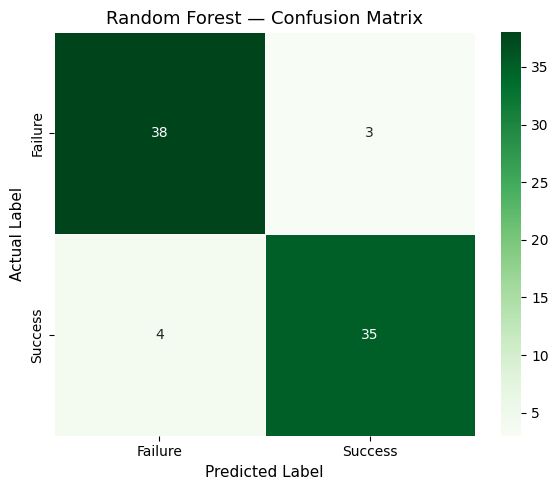

TN=38  FP=3
FN=4  TP=35


In [28]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5)

plt.title('Random Forest — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/rf_confusion_matrix.png', dpi=150)
plt.show()

print(f"TN={cm_rf[0,0]}  FP={cm_rf[0,1]}")
print(f"FN={cm_rf[1,0]}  TP={cm_rf[1,1]}")

In [29]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("FEATURE IMPORTANCE RANKING")
print("=" * 45)
for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"{row['feature']:20s} {row['importance']:.4f}  {bar}")

FEATURE IMPORTANCE RANKING
marketing_budget     0.3296  ████████████████
competition          0.2028  ██████████
price                0.1902  █████████
timing               0.1455  ███████
region               0.0861  ████
category             0.0459  ██


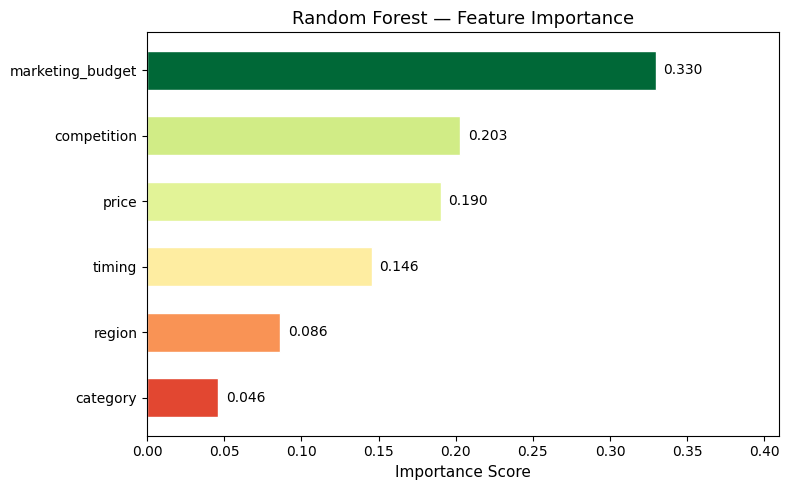

Saved!


In [30]:
colors = plt.cm.RdYlGn(
    importance_df['importance'] / importance_df['importance'].max()
)

plt.figure(figsize=(8, 5))
bars = plt.barh(importance_df['feature'],
                importance_df['importance'],
                color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, importance_df['importance']):
    plt.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Random Forest — Feature Importance', fontsize=13)
plt.xlabel('Importance Score', fontsize=11)
plt.xlim(0, importance_df['importance'].max() + 0.08)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/feature_importance.png', dpi=150)
plt.show()
print("Saved!")

In [31]:
joblib.dump(rf_model, '../models/best_model.pkl')
print(f"Saved! Size: {os.path.getsize('../models/best_model.pkl'):,} bytes")

Saved! Size: 832,025 bytes


In [38]:
loaded = joblib.load('../models/best_model.pkl')
sample = X_test.iloc[[0]]

if rf_model.predict(sample)[0] == loaded.predict(sample)[0]:
    print("VERIFICATION PASSED — model ready for Day 7!")
else:
    print("VERIFICATION FAILED — re-run Cell 10!")

VERIFICATION PASSED — model ready for Day 7!


In [36]:
results = {
    'Logistic Regression': {
        'accuracy':  0.8750,   # ← paste Day 3 number
        'precision': 0.8919,   # ← paste Day 3 number
        'recall':    0.8462,   # ← paste Day 3 number
        'f1':        0.8684    # ← paste Day 3 number
    },
    'Decision Tree': {
        'accuracy':  0.8500,   # ← paste Day 4 number
        'precision': 0.8649,   # ← paste Day 4 number
        'recall':    0.8205,   # ← paste Day 4 number
        'f1':        0.8421    # ← paste Day 4 number
    },
    'Random Forest': {
        'accuracy':  round(rf_accuracy,  4),
        'precision': round(rf_precision, 4),
        'recall':    round(rf_recall,    4),
        'f1':        round(rf_f1,        4)
    }
}

print(f"{'Model':<22} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-" * 58)
for model, m in results.items():
    print(f"{model:<22} {m['accuracy']:>8.4f} {m['precision']:>8.4f} {m['recall']:>8.4f} {m['f1']:>8.4f}")

best = max(results, key=lambda x: results[x]['f1'])
print(f"\nBest model: {best}")

Model                       Acc     Prec      Rec       F1
----------------------------------------------------------
Logistic Regression      0.8750   0.8919   0.8462   0.8684
Decision Tree            0.8500   0.8649   0.8205   0.8421
Random Forest            0.9125   0.9211   0.8974   0.9091

Best model: Random Forest


In [34]:
for f in ['../plots/rf_confusion_matrix.png',
          '../plots/feature_importance.png',
          '../models/best_model.pkl']:
    status = "EXISTS" if os.path.exists(f) else "MISSING"
    print(f"{status}: {f}")

EXISTS: ../plots/rf_confusion_matrix.png
EXISTS: ../plots/feature_importance.png
EXISTS: ../models/best_model.pkl


In [37]:
import joblib
joblib.dump(rf_model, '../models/best_model.pkl')
print(f"Model saved: {os.path.getsize('../models/best_model.pkl'):,} bytes")

Model saved: 832,025 bytes
